#### xgBoost

Loading preprocessed data …
  Train: 472,443  |  fraud rate: 3.499%
  Val  : 29,516  |  fraud rate: 3.500%
  scale_pos_weight = 27.6

Training XGBoost with PR-AUC tracking and best checkpointing

   Round  Train Loss  Val PR-AUC     Time
  ------  ----------  ----------  -------
       1      0.6729      0.3227     0.7s ◀ best
       2      0.6550      0.3662     0.1s ◀ best
       3      0.6384      0.3721     0.0s ◀ best
       4      0.6236      0.3725     0.1s ◀ best
       5      0.6095      0.3964     0.1s ◀ best
       6      0.5962      0.3997     0.1s ◀ best
       7      0.5840      0.4052     0.1s ◀ best
       8      0.5725      0.4060     0.1s ◀ best
       9      0.5615      0.4120     0.1s ◀ best
      11      0.5426      0.4202     0.1s ◀ best
      12      0.5342      0.4288     0.1s ◀ best
      13      0.5269      0.4469     0.1s ◀ best
      14      0.5192      0.4470     0.1s ◀ best
      15      0.5115      0.4559     0.1s ◀ best
      16      0.5045      0.4599  

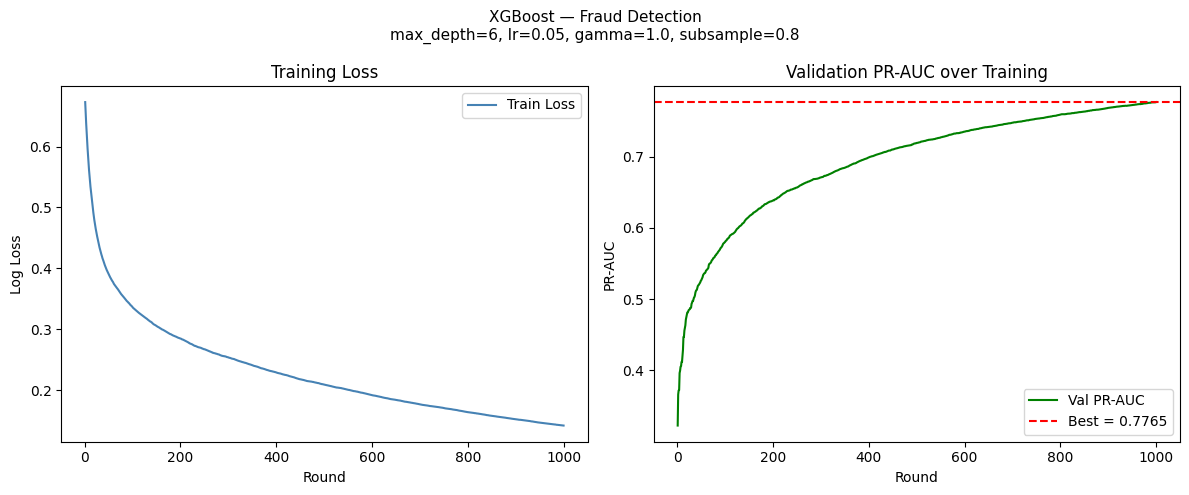

Training curves saved to models/xgboost/xgb_training_curves.png


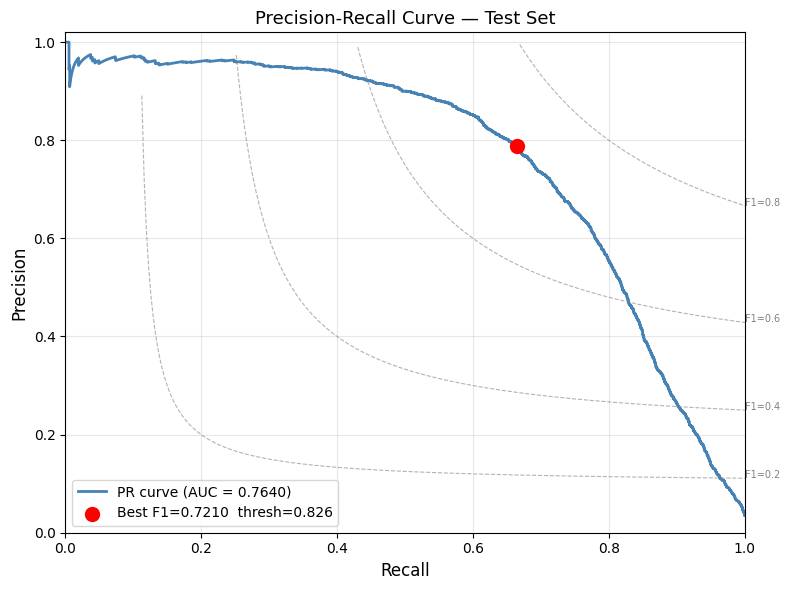

PR curve saved to models/xgboost/pr_curve.png

  Final Results at best threshold = 0.826
  Test PR-AUC   : 0.7640
  Test F1       : 0.7210
  Test Recall   : 0.6647
  Test Precision: 0.7878
  Val  Recall   : 0.6350

Top 20 features by gain:
V70               5382.668457
C8                2389.659912
V91               2336.609375
V308              1560.882812
card6_freq        1350.706909
C4                1208.732422
C14               1085.591064
V94                979.906006
C12                896.660645
card3_amt_mean     879.145142
V317               857.469482
card6              810.157104
V283               788.489319
V48                571.542175
C1                 439.594543
V45                434.896942
V133               420.144409
V69                419.693970
V29                374.030853
V102               368.168396

Model saved → models/xgboost/xgb_fraud.ubj
Final metrics saved to models/xgboost/final_metrics.json

  All outputs saved to: models/xgboost/
    xgb_training_c

: 

In [ ]:
"""
XGBoost Fraud Detection — PR-AUC primary metric, training history,
checkpointing, training curves, PR curve, final metrics JSON
"""

import io
import json
import pickle
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xgboost as xgb
from sklearn.metrics import (
    average_precision_score,
    classification_report,
    f1_score,
    precision_recall_curve,
    recall_score,
    roc_auc_score,
)

# ── Config ────────────────────────────────────────────────────────────────────
DATA_DIR   = Path("")
OUTPUT_DIR = Path("models/xgboost")
SEED       = 42
EARLY_STOP = 50

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# ── Load data ─────────────────────────────────────────────────────────────────
def load_data():
    print("Loading preprocessed data …")
    with open(DATA_DIR / "column_metadata.pkl", "rb") as f:
        meta = pickle.load(f)

    target = meta["target"]

    train = pd.read_csv(DATA_DIR / "train.csv")
    val   = pd.read_csv(DATA_DIR / "val.csv")
    test  = pd.read_csv(DATA_DIR / "test.csv")

    feature_cols = [c for c in train.columns if c != target]

    X_train, y_train = train[feature_cols].values, train[target].values
    X_val,   y_val   = val[feature_cols].values,   val[target].values
    X_test,  y_test  = test[feature_cols].values,  test[target].values

    neg, pos         = (y_train == 0).sum(), (y_train == 1).sum()
    scale_pos_weight = neg / pos
    print(f"  Train: {len(y_train):,}  |  fraud rate: {y_train.mean():.3%}")
    print(f"  Val  : {len(y_val):,}  |  fraud rate: {y_val.mean():.3%}")
    print(f"  scale_pos_weight = {scale_pos_weight:.1f}")

    dtrain = xgb.DMatrix(X_train, label=y_train, feature_names=list(feature_cols))
    dval   = xgb.DMatrix(X_val,   label=y_val,   feature_names=list(feature_cols))
    dtest  = xgb.DMatrix(X_test,  label=y_test,  feature_names=list(feature_cols))

    return dtrain, dval, dtest, y_val, y_test, scale_pos_weight


# ── Callback: history + checkpointing ────────────────────────────────────────
class PRaucCallback(xgb.callback.TrainingCallback):
    def __init__(self, dval, y_val, output_dir, log_interval=50):
        self.dval         = dval
        self.y_val        = y_val
        self.output_dir   = Path(output_dir)
        self.log_interval = log_interval

        self.best_val_pr  = 0.0
        self.best_round   = 0
        self.best_model   = None

        self.history      = {"round": [], "train_logloss": [], "val_pr_auc": [], "time_s": []}
        self._t0          = None

        print(f"\n  {'Round':>6}  {'Train Loss':>10}  {'Val PR-AUC':>10}  {'Time':>7}")
        print(f"  {'-'*6}  {'-'*10}  {'-'*10}  {'-'*7}")

    def before_training(self, model):
        self._t0 = time.time()
        return model

    def after_iteration(self, model, epoch, evals_log):
        elapsed    = time.time() - self._t0
        self._t0   = time.time()

        train_loss = evals_log.get("train", {}).get("logloss", [None])[-1]
        val_probs  = model.predict(self.dval)
        val_pr     = average_precision_score(self.y_val, val_probs)

        # Checkpoint
        if val_pr > self.best_val_pr:
            self.best_val_pr = val_pr
            self.best_round  = epoch + 1
            tmp_path = self.output_dir / "_best_checkpoint.ubj"
            model.save_model(str(tmp_path))
            self.best_model = str(tmp_path)

        # Log
        self.history["round"].append(epoch + 1)
        self.history["train_logloss"].append(round(train_loss, 4) if train_loss else None)
        self.history["val_pr_auc"].append(round(val_pr, 4))
        self.history["time_s"].append(round(elapsed, 1))

        marker = " ◀ best" if val_pr >= self.best_val_pr else ""
        if (epoch + 1) % self.log_interval == 0 or marker:
            print(
                f"  {epoch+1:>6}  "
                f"{train_loss:>10.4f}  "
                f"{val_pr:>10.4f}  "
                f"{elapsed:>6.1f}s"
                f"{marker}"
            )

        pd.DataFrame(self.history).to_csv(
            self.output_dir / "training_log.csv", index=False
        )
        return False

    def after_training(self, model):
        print(f"\n  Best val PR-AUC: {self.best_val_pr:.4f} at round {self.best_round}")
        return model


# ── Train ─────────────────────────────────────────────────────────────────────
def train(dtrain, dval, y_val, scale_pos_weight):
    print(f"\n{'='*60}")
    print("Training XGBoost with PR-AUC tracking and best checkpointing")
    print(f"{'='*60}")

    params = {
        "objective":        "binary:logistic",
        "eval_metric":      ["logloss", "auc"],
        "tree_method":      "hist",
        "seed":             SEED,
        "verbosity":        0,
        "scale_pos_weight": scale_pos_weight,
        "max_depth":        6,
        "learning_rate":    0.05,
        "min_child_weight": 5,
        "subsample":        0.8,
        "colsample_bytree": 0.8,
        "gamma":            1.0,
        "reg_alpha":        0.1,
        "reg_lambda":       1.0,
    }

    callback = PRaucCallback(dval=dval, y_val=y_val, output_dir=OUTPUT_DIR)

    model = xgb.train(
        params,
        dtrain,
        num_boost_round       = 1000,
        evals                 = [(dtrain, "train"), (dval, "val")],
        early_stopping_rounds = EARLY_STOP,
        callbacks             = [callback],
        verbose_eval          = False,
    )

    # Restore best checkpoint
    best_model = xgb.Booster()
    best_model.load_model(callback.best_model)
    print(f"  Restored best model from round {callback.best_round}")

    return best_model, callback.history, callback.best_val_pr, params


# ── Plot training curves ──────────────────────────────────────────────────────
def plot_training_curves(history, best_val_pr, params):
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    ax = axes[0]
    ax.plot(history["round"], history["train_logloss"], label="Train Loss", color="steelblue")
    ax.set_xlabel("Round")
    ax.set_ylabel("Log Loss")
    ax.set_title("Training Loss")
    ax.legend()

    ax = axes[1]
    ax.plot(history["round"], history["val_pr_auc"], label="Val PR-AUC", color="green")
    ax.axhline(
        y=best_val_pr, color="red", linestyle="--",
        label=f"Best = {best_val_pr:.4f}"
    )
    ax.set_xlabel("Round")
    ax.set_ylabel("PR-AUC")
    ax.set_title("Validation PR-AUC over Training")
    ax.legend()

    cfg_label = (
        f"max_depth={params['max_depth']}, lr={params['learning_rate']}, "
        f"gamma={params['gamma']}, subsample={params['subsample']}"
    )
    plt.suptitle(f"XGBoost — Fraud Detection\n{cfg_label}", fontsize=11)
    plt.tight_layout()

    curves_path = OUTPUT_DIR / "xgb_training_curves.png"
    plt.savefig(curves_path, dpi=150)
    plt.show()
    print(f"Training curves saved to {curves_path}")


# ── Plot PR curve ─────────────────────────────────────────────────────────────
def plot_pr_curve(y_true, y_proba, test_pr):
    precision_pts, recall_pts, thresholds = precision_recall_curve(y_true, y_proba)

    # Best threshold by F1
    f1_scores   = (
        2 * precision_pts[:-1] * recall_pts[:-1]
        / (precision_pts[:-1] + recall_pts[:-1] + 1e-8)
    )
    best_idx       = np.argmax(f1_scores)
    best_thresh    = float(thresholds[best_idx])
    best_f1        = float(f1_scores[best_idx])
    best_recall    = float(recall_pts[best_idx])
    best_precision = float(precision_pts[best_idx])

    fig, ax = plt.subplots(figsize=(8, 6))
    ax.plot(recall_pts, precision_pts, color="steelblue", lw=2,
            label=f"PR curve (AUC = {test_pr:.4f})")
    ax.scatter(best_recall, best_precision, color="red", zorder=5, s=100,
               label=f"Best F1={best_f1:.4f}  thresh={best_thresh:.3f}")

    # ISO F1 contours
    for f1_iso in [0.2, 0.4, 0.6, 0.8]:
        r_vals = np.linspace(0.01, 1.0, 300)
        p_vals = f1_iso * r_vals / (2 * r_vals - f1_iso + 1e-8)
        mask   = (p_vals >= 0) & (p_vals <= 1)
        ax.plot(r_vals[mask], p_vals[mask], "--", color="grey", lw=0.8, alpha=0.6)
        ax.annotate(f"F1={f1_iso}", xy=(r_vals[mask][-1], p_vals[mask][-1]),
                    fontsize=7, color="grey")

    ax.set_xlabel("Recall",    fontsize=12)
    ax.set_ylabel("Precision", fontsize=12)
    ax.set_title("Precision-Recall Curve — Test Set", fontsize=13)
    ax.set_xlim([0, 1]); ax.set_ylim([0, 1.02])
    ax.legend(fontsize=10); ax.grid(alpha=0.3)
    plt.tight_layout()

    pr_curve_path = OUTPUT_DIR / "pr_curve.png"
    plt.savefig(pr_curve_path, dpi=150)
    plt.show()
    print(f"PR curve saved to {pr_curve_path}")

    return best_thresh, best_f1, best_recall, best_precision


# ── Evaluate ──────────────────────────────────────────────────────────────────
def evaluate(model, dmat, y_true, split_name):
    probs  = model.predict(dmat)
    auc    = roc_auc_score(y_true, probs)
    pr_auc = average_precision_score(y_true, probs)

    print(f"\n{'='*50}")
    print(f"  Checkpoint PR-AUC (recall deferred to PR curve)")
    print(f"{'='*50}")
    print(f"  {split_name} PR-AUC : {pr_auc:.4f}")
    print(f"  {split_name} ROC-AUC: {auc:.4f}")

    return pr_auc, probs


# ── Feature importance ────────────────────────────────────────────────────────
def show_feature_importance(model, top_n=20):
    scores = model.get_score(importance_type="gain")
    imp    = pd.Series(scores).sort_values(ascending=False).head(top_n)
    print(f"\nTop {top_n} features by gain:")
    print(imp.to_string())
    imp.to_csv(OUTPUT_DIR / "feature_importance.csv", header=["gain"])


# ── Main ──────────────────────────────────────────────────────────────────────
def main():
    dtrain, dval, dtest, y_val, y_test, spw = load_data()

    # ── Train ──────────────────────────────────────────────────────────────
    t0                            = time.time()
    model, history, best_val_pr, params = train(dtrain, dval, y_val, spw)
    print(f"\nTotal training time: {time.time()-t0:.1f}s")

    # ── Evaluate checkpoint PR-AUC ─────────────────────────────────────────
    val_pr,  val_probs  = evaluate(model, dval,  y_val,  "Val ")
    test_pr, test_probs = evaluate(model, dtest, y_test, "Test")

    # ── Training curves ────────────────────────────────────────────────────
    plot_training_curves(history, best_val_pr, params)

    # ── PR curve + best threshold ──────────────────────────────────────────
    best_thresh, best_f1, test_recall, test_precision = plot_pr_curve(
        y_test, test_probs, test_pr
    )

    # ── Recall at best threshold on val set ───────────────────────────────
    val_recall = recall_score(
        y_val, (val_probs >= best_thresh).astype(int), zero_division=0
    )

    # ── Final summary ──────────────────────────────────────────────────────
    print(f"\n{'='*50}")
    print(f"  Final Results at best threshold = {best_thresh:.3f}")
    print(f"{'='*50}")
    print(f"  Test PR-AUC   : {test_pr:.4f}")
    print(f"  Test F1       : {best_f1:.4f}")
    print(f"  Test Recall   : {test_recall:.4f}")
    print(f"  Test Precision: {test_precision:.4f}")
    print(f"  Val  Recall   : {val_recall:.4f}")

    # ── Feature importance ─────────────────────────────────────────────────
    show_feature_importance(model)

    # ── Save model ─────────────────────────────────────────────────────────
    model_path = OUTPUT_DIR / "xgb_fraud.ubj"
    model.save_model(model_path)
    print(f"\nModel saved → {model_path}")

    # ── Save predictions ───────────────────────────────────────────────────
    pd.DataFrame({
        "fraud_prob": test_probs,
        "pred":       (test_probs >= best_thresh).astype(int),
    }).to_csv(OUTPUT_DIR / "test_predictions.csv", index=False)

    # ── Save final metrics JSON ────────────────────────────────────────────
    final_metrics = {
        "best_params":     {k: v for k, v in params.items()
                            if k not in ("eval_metric", "verbosity")},
        "val_pr_auc":      val_pr,
        "test_pr_auc":     test_pr,
        "best_thresh":     best_thresh,
        "test_f1":         best_f1,
        "test_recall":     test_recall,
        "test_precision":  test_precision,
        "val_recall":      val_recall,
    }
    metrics_path = OUTPUT_DIR / "final_metrics.json"
    with open(metrics_path, "w") as f:
        json.dump(final_metrics, f, indent=2)
    print(f"Final metrics saved to {metrics_path}")

    # ── Output summary ─────────────────────────────────────────────────────
    print(f"\n{'='*50}")
    print(f"  All outputs saved to: {OUTPUT_DIR}/")
    print(f"    xgb_training_curves.png")
    print(f"    pr_curve.png")
    print(f"    feature_importance.csv")
    print(f"    training_log.csv")
    print(f"    test_predictions.csv")
    print(f"    final_metrics.json")
    print(f"    xgb_fraud.ubj")
    print(f"{'='*50}")

    return model, val_pr, test_pr


if __name__ == "__main__":
    main()